<a href="https://colab.research.google.com/github/isisbia/am-t5/blob/main/laboratorios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Célula 1: Análise Exploratória (Gera os Gráficos da Apresentação)

1. RESUMO GERAL DO DATASET
Total de Registos (Escolas): 214,192
Total de Atributos (Colunas): 290

2. ANÁLISE DO TARGET: IN_LABORATORIO_INFORMATICA
Sem Laboratório (0): 128,438 escolas (59.96%)
Com Laboratório (1): 52,102 escolas (24.32%)
Nulo/Não informado: 33,652 escolas (15.71%)

3. ANÁLISE DOS TIPOS DE DADOS
Variáveis Numéricas: 278
Variáveis Categóricas/Texto: 12


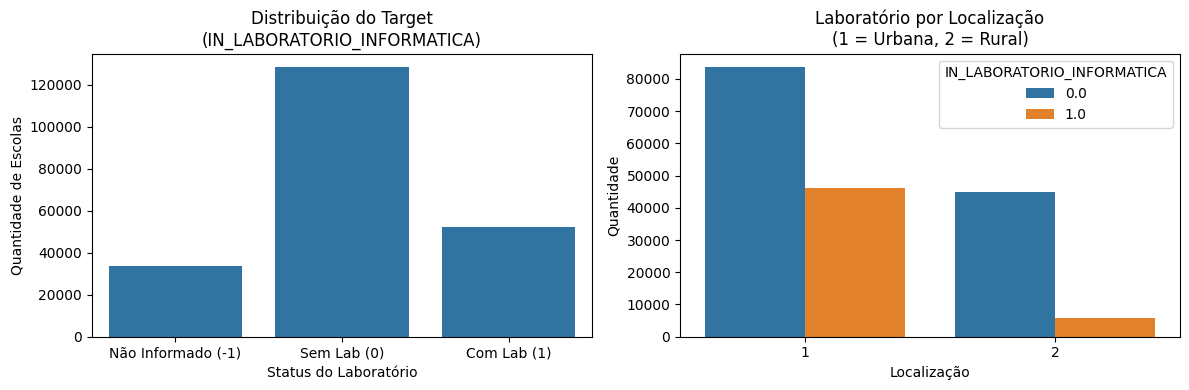

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

caminho_arquivo = '/content/drive/MyDrive/am-t6/Tabela_Escola_2025_V2.csv'
df = pd.read_csv(caminho_arquivo, encoding='latin1', sep=';', low_memory=False)

print("="*50)
print("1. RESUMO GERAL DO DATASET")
print("="*50)
print(f"Total de Registos (Escolas): {len(df):,}")
print(f"Total de Atributos (Colunas): {df.shape[1]}")

target_col = 'IN_LABORATORIO_INFORMATICA'
print("\n" + "="*50)
print(f"2. ANÁLISE DO TARGET: {target_col}")
print("="*50)

counts = df[target_col].value_counts(dropna=False)
perc = df[target_col].value_counts(normalize=True, dropna=False) * 100

print(f"Sem Laboratório (0): {counts.get(0.0, 0):,} escolas ({perc.get(0.0, 0):.2f}%)")
print(f"Com Laboratório (1): {counts.get(1.0, 0):,} escolas ({perc.get(1.0, 0):.2f}%)")
nulos = df[target_col].isna().sum()
print(f"Nulo/Não informado: {nulos:,} escolas ({(nulos/len(df))*100:.2f}%)")

cat_cols = df.select_dtypes(include=['object', 'category']).columns
num_cols = df.select_dtypes(include=[np.number]).columns

print("\n" + "="*50)
print("3. ANÁLISE DOS TIPOS DE DADOS")
print("="*50)
print(f"Variáveis Numéricas: {len(num_cols)}")
print(f"Variáveis Categóricas/Texto: {len(cat_cols)}")

plt.figure(figsize=(12, 4))

target_rotulado = df[target_col].map({0.0: 'Sem Lab (0)', 1.0: 'Com Lab (1)'}).fillna('Não Informado (-1)')

plt.subplot(1, 2, 1)
sns.countplot(x=target_rotulado, order=['Não Informado (-1)', 'Sem Lab (0)', 'Com Lab (1)'])
plt.title('Distribuição do Target\n(IN_LABORATORIO_INFORMATICA)')
plt.xlabel('Status do Laboratório')
plt.ylabel('Quantidade de Escolas')

plt.subplot(1, 2, 2)
if 'TP_LOCALIZACAO' in df.columns:
    sns.countplot(data=df, x='TP_LOCALIZACAO', hue=target_col)
    plt.title('Laboratório por Localização\n(1 = Urbana, 2 = Rural)')
    plt.xlabel('Localização')
    plt.ylabel('Quantidade')

plt.tight_layout()
plt.show()

# Célula 2: Limpeza Otimizada + Exportação PKL e BIN (Super Rápida)

In [ ]:
import pickle

print("Iniciando Limpeza e Tratamento...")

df_clean = df.dropna(subset=[target_col]).copy()
y = df_clean[target_col].astype(np.int8)

limite = 0.5 * len(df_clean)
df_clean = df_clean.dropna(thresh=limite, axis=1)

cols_para_remover = [
    target_col, 'CO_ENTIDADE', 'NO_ENTIDADE', 'NU_CNPJ_ESCOLA_PRIVADA',
    'NU_CNPJ_MANTENEDORA', 'DT_ANO_LETIVO_INICIO', 'DT_ANO_LETIVO_TERMINO',
    'NO_MUNICIPIO', 'NO_DISTRITO', 'NO_SUBDISTRITO', 'NO_REGIAO_GEOG_INTERM',
    'NO_REGIAO_GEOG_IMED', 'NO_UF'
]
X_raw = df_clean.drop(columns=[c for c in cols_para_remover if c in df_clean.columns])

num_cols = X_raw.select_dtypes(include=[np.number]).columns
X_raw[num_cols] = X_raw[num_cols].fillna(X_raw[num_cols].median())

cat_cols = X_raw.select_dtypes(include=['object', 'category']).columns
X_raw[cat_cols] = X_raw[cat_cols].fillna('NAO_INFORMADO')
X_processed = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True, dtype=np.int8)

print(f"✅ Limpeza concluída! Matriz de Features final (X): {X_processed.shape}")

dataset_dict = {
    'X': X_processed,
    'y': y,
    'feature_names': list(X_processed.columns)
}
with open('dataset_processado.pkl', 'wb') as f:
    pickle.dump(dataset_dict, f, protocol=pickle.HIGHEST_PROTOCOL)

with open('X_data.bin', 'wb') as f:
    f.write(X_processed.values.astype(np.float32).tobytes())

with open('y_data.bin', 'wb') as f:
    f.write(y.values.astype(np.int32).tobytes())

print("✅ Arquivos 'dataset_processado.pkl', 'X_data.bin' e 'y_data.bin' gerados!")

Iniciando Limpeza e Tratamento...
✅ Limpeza concluída! Matriz de Features final (X): (180540, 517)
✅ Arquivos 'dataset_processado.pkl', 'X_data.bin' e 'y_data.bin' gerados!
